In [1]:
from jacobian import get_jacobian

In [2]:
import submitDACCAD
from ReservoirRun import Reservoir
import numpy as np
from numpy import linalg as LA
import os
from datetime import datetime
from evolver import DaccadBioneatMut
from evolver import DaccadBioneatMut_smaller
from qdpy.containers import *
from individual import *

In [4]:
min_stability = []
nb_template = []

grid = Grid(shape=(10,10), max_items_per_bin=1, fitness_domain=((0., 1.),), features_domain=((0., 1.), (0., 1.)))

for _ in range(100):
    evo = DaccadBioneatMut_smaller(grid, 10, [0.0,200.0], nb_nodes_domain=[2,2])
    indiv = evo.ask()
    print("indiv: ", indiv)
    
    daccadIndiv = indiv
    config = {'daccad': {'path':'../../daccad'}}
    scales = [1000.0, 200.0]
    npeaks = 1
    nNodes = daccadIndiv.nb_nodes
    print("nNodes : ", nNodes)
    stabilities = daccadIndiv.stabilities
    print("stabilities : ", stabilities)
    min_stability.append(min(stabilities))
    
    scaling = [scales[0]]*nNodes+[scales[1]]*(nNodes*nNodes*(nNodes+1))
    myarray = np.array(scaling)*np.array(daccadIndiv)
    jikeiretu = submitDACCAD.submitPENSystem_input(myarray, nNodes = nNodes, executablePath=config['daccad']['path'],
                                                 configFile = os.path.abspath(os.getcwd())+"/" + '../daccadConf.conf', 
                                                 jsonFileName=os.path.abspath(os.getcwd())+"/"+"."+"/"+datetime.now().isoformat(timespec='microseconds')+".json",
                                                 configFile_input = os.path.abspath(os.getcwd())+"/" + "../config_mc.json"
                                                 ).decode('ascii')
    jikeiretu_arr = [[float(a) for a in line.split(',')] for line in jikeiretu.split('\n')[3003:-1]]
    # f = pd.DataFrame(arr)
    # print("jikeiretu : ")
    # print(jikeiretu_arr)
    
    print("the number of template : ", len(jikeiretu_arr[0]) - 2)
    nb_template.append(len(jikeiretu_arr[0]) - 2)
    
    matrix = np.zeros([7, 7])
    matrix = get_jacobian(myarray, jikeiretu_arr[-1])
    w, v = LA.eig(matrix)
    
    eigenvalues.append(np.mean([np.linalg.norm(val) for val in w]))

indiv:  DaccadIndividual([0.01, 0.01, 27.119446900642853, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.01, 0.01]
the number of template :  10
indiv:  DaccadIndividual([0.005312793757875783, 0.006437037782286397, 0.0, 0.049396628971801526, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.005312793757875783, 0.006437037782286397]
the number of template :  5
indiv:  DaccadIndividual([0.0051, 0.01, 0.0, 0.020747022086062442, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.0051, 0.01]
the number of template :  5
indiv:  DaccadIndividual([0.013515215884669175, 0.01, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.013515215884669175, 0.01]
the number of template :  5
indiv:  DaccadIndividual([0.0051632323715529345, 0.01, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.0051632323715529345, 0.01]
the

the number of template :  5
indiv:  DaccadIndividual([0.017042653138247574, 0.01, 0.0, 0.02910966082111574, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.017042653138247574, 0.01]
the number of template :  5
indiv:  DaccadIndividual([0.03363491300119907, 0.01764257608508089, 0.0, 0.0051, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.03363491300119907, 0.01764257608508089]
the number of template :  5
indiv:  DaccadIndividual([0.0076646751814936475, 0.01, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.0076646751814936475, 0.01]
the number of template :  5
indiv:  DaccadIndividual([0.018041868846754447, 0.009323565794442736, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.018041868846754447, 0.009323565794442736]
the number of template :  5
indiv:  DaccadIndividual([0.027331662275897867, 0.014195444624989064, 0.0, 0.04260469856977

the number of template :  5
indiv:  DaccadIndividual([0.016742034480408494, 0.010013204925720469, 0.0, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.016742034480408494, 0.010013204925720469]
the number of template :  5
indiv:  DaccadIndividual([0.01, 0.01, 176.7328634014342, 0.025, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.01, 0.01]
the number of template :  10
indiv:  DaccadIndividual([0.007047802261492838, 0.015996859288166656, 0.0, 0.016955929153532157, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.007047802261492838, 0.015996859288166656]
the number of template :  5
indiv:  DaccadIndividual([0.01200042402110173, 0.01, 0.0, 0.0051, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
nNodes :  2
stabilities :  [0.01200042402110173, 0.01]
the number of template :  5
indiv:  DaccadIndividual([0.01, 0.01, 0.0, 0.025, 191.71605253637068, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

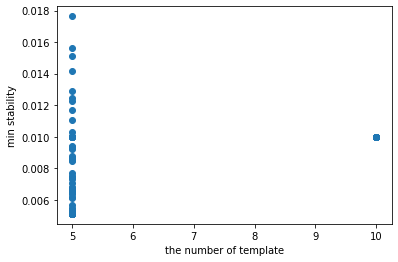

In [5]:
import matplotlib.pyplot as plt
plt.xlabel("the number of template")
plt.ylabel("min stability")
plt.scatter(nb_template, min_stability)